# <img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/Python-logo-notext.svg" width="35" alt="Python Logo"> Stack de Dados Módulo 4: Visualização de Dados

Nesta etapa vamos dar vida aos nossos dados. No módulo anterior nós agrupamos as categorias e cruzamos as tabelas para extrair métricas. Agora chegou o momento em que os números se transformam em imagens claras e profissionais. O analista deixa de olhar para matrizes complexas e passa a criar gráficos que apoiam a tomada de decisão de forma totalmente visual. Essa é a fase onde revelamos tendências e padrões usando as ferramentas certas.

### O que vamos construir agora?
Vamos dominar quatro pilares fundamentais para desenhar as estatísticas da nossa base.
* **Matplotlib:** Como funciona a estrutura de um gráfico controlando figuras e eixos espaciais.
* **Seaborn:** Como criar paletas de cores modernas e gráficos complexos com poucas linhas de código.
* **Personalização:** Como customizar títulos e rótulos para deixar a sua apresentação com um acabamento corporativo.
* **Exportação:** Como salvar as suas criações como imagens prontas para ilustrar relatórios executivos.

## 🗂️ Relembrando nosso Dataset

Neste módulo continuaremos explorando os registros oficiais do **Centro de Investigação e Prevenção de Acidentes Aeronáuticos (CENIPA)**. Como já conhecemos bem esta base desde o [Módulo 3](/python/02-stack-dados/manipulacao-e-estruturacao-dados/modulo-3.ipynb), vamos direto ao ponto. Seguiremos utilizando as mesmas tabelas que integramos na etapa anterior, mas agora com o foco total em gerar os nossos gráficos e painéis.

### 📊 Estrutura dos Arquivos
Para as nossas visualizações trabalharemos com as duas tabelas conectadas:

* **Tabela de Ocorrências:** traz os dados gerais do evento como localidade, datas, horários e classificações da gravidade.
* **Tabela de Aeronaves:** contém os detalhes técnicos dos equipamentos envolvidos como fabricante, motorização, danos sofridos e operação.

### 📥 Relembrando o acesso
Caso precise carregar os dados novamente em um novo caderno de estudos, os arquivos formatados continuam disponíveis:

1. **No repositório local:** Eles estão organizados dentro da pasta `arquivos-e-imagens` com os nomes [CENIPA_ocorrencias.csv](../arquivos-e-imagens/CENIPA_ocorrencias.csv) e [CENIPA_ocorrencia_aeronave.csv](../arquivos-e-imagens/CENIPA_ocorrencia_aeronave.csv).
2. **Na fonte oficial:** Sempre disponíveis na página do [Portal de Dados Abertos](https://dados.gov.br/dados/conjuntos-dados/ocorrencias-aeronauticas-da-aviacao-civil-brasileira) do Governo Federal.

In [2]:
import pandas as pd
df_ocorrencias = pd.read_csv("../arquivos-e-imagens/CENIPA_ocorrencias.csv", sep=";", encoding="latin1")
df_aeronaves = pd.read_csv("../arquivos-e-imagens/CENIPA_ocorrencia_aeronave.csv", sep=";", encoding="latin1")

# Aplicando filtros realizados no Modulo 2 anteriormente para prosseguirmos com nossa análise
colunas_apagadas = ["codigo_ocorrencia", "codigo_ocorrencia1", "codigo_ocorrencia3", "codigo_ocorrencia4", "ocorrencia_pais"]
df_ocorrencias = df_ocorrencias.drop(colunas_apagadas, axis=1)

df_ocorrencias.head()

,codigo_ocorrencia2,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_aerodromo,ocorrencia_dia,ocorrencia_hora,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista
0,88808,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,19/04/2026,04:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
1,88804,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,SBGR,23/04/2026,15:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
2,88794,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,28/04/2026,18:36:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
3,88783,INCIDENTE,-22.81,-43.25055555555,RIO DE JANEIRO,RJ,SBGL,30/04/2026,19:30:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
4,88769,INCIDENTE GRAVE,-12.90861111111,-38.3225,SALVADOR,BA,SBSV,09/05/2026,19:15:00,SIM,ATIVA,A DEFINIR,NÃO,NaN,0,1,SIM


### Importando as Bibliotecas
Agora que os nossos dados já estão carregados, o próximo passo é chamar as ferramentas que vão construir as nossas imagens. Assim, vamos utilizar as duas bibliotecas de visualização mais importantes do ecossistema Python:

* **Matplotlib:** é a base estrutural. Ela permite controlar cada linha, eixo, título e margem do seu gráfico. Vamos importar o seu módulo principal de plotagem e apelidar carinhosamente de `plt`. Você pode conferir a documentação completa no site oficial: [Matplotlib (Site Oficial)](https://matplotlib.org/).
* **Seaborn:** construída sobre o Matplotlib, ela automatiza a criação de gráficos estatísticos e entrega um visual muito mais limpo e moderno por padrão. Vamos apelidar de `sns`. O site oficial é o [Seaborn (Site Oficial)](https://seaborn.pydata.org/).

**Configuração Inicial**
Em vez de ajustar o tamanho das imagens toda vez que formos criar um gráfico novo, nós podemos usar uma função do Matplotlib para definir uma largura e uma altura padrão. Isso garante que todos os gráficos do nosso caderno terão o mesmo tamanho e manterão uma consistência visual profissional do começo ao fim.

In [3]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo um tamanho padrao para todos os graficos do caderno
# Os valores representam (Largura, Altura) em polegadas
plt.rcParams["figure.figsize"] = (12, 6)

# Aplicando o tema whitegrid do Seaborn para melhorar a estetica geral
# Outras opcoes de temas disponiveis: darkgrid, dark, white e ticks
sns.set_theme(style="whitegrid")

**Temas**

* **whitegrid:** fundo branco com linhas de grade (ideal para facilitar a leitura de valores exatos)

* **darkgrid:** fundo cinza com linhas de grade brancas (o estilo visual padrão do Seaborn)

* **white:** fundo limpo totalmente branco e sem linhas de grade

* **dark:** fundo cinza sem linhas de grade

* **ticks:** fundo branco com pequenas marcas destacando a divisão dos eixos

### Construção Gráfica: plt.bar
O comando `plt.bar`usado abaixo é a maneira mais simples e direta de levantar um gráfico visualmente. Você só precisa entregar as categorias textuais de um lado e os valores numéricos do outro. Embora existam ferramentas mais robustas, dominar essa simplicidade absoluta do Matplotlib é o primeiro grande passo de qualquer analista na hora de desenhar resultados.

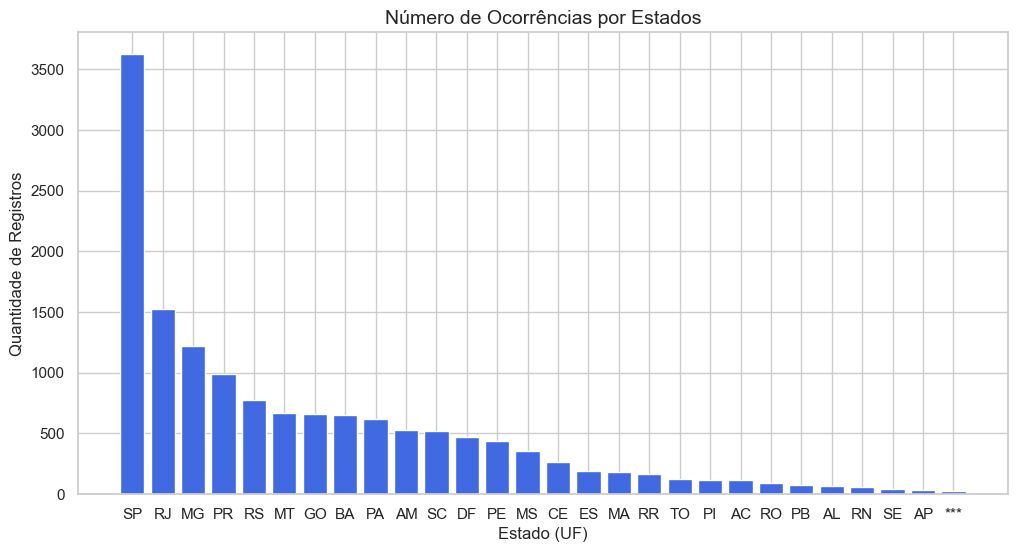

In [12]:
# 1. Contando as ocorrencias por Estado (UF) e selecionando os 10 primeiros
# O comando value_counts() faz a contagem do maior para o menor automaticamente
contagem_estados = df_ocorrencias["ocorrencia_uf"].value_counts()

# 2. Desenhando as barras verticais
# A funcao plt.bar pede duas informacoes principais: os rotulos do eixo X e os valores do eixo Y
# contagem_estados.index trará as siglas dos Estados e a
# contagem_estados.values trará a quantidade numerica de acidentes e incidentes
plt.bar(contagem_estados.index, contagem_estados.values, color="royalblue")

# 3. Adicionando os legendas agora com o comando plt.title(), plt.xlabel() e plt.ylabel()
plt.title("Número de Ocorrências por Estados", fontsize=14)
plt.xlabel("Estado (UF)", fontsize=12)
plt.ylabel("Quantidade de Registros", fontsize=12)

# 4. O comando plt.show() finaliza o desenho e exibe o grafico limpo na tela
plt.show()

### Linhas do Tempo com o plt.plot()

Enquanto o gráfico de barras é excelente para comparar categorias ou grupos diferentes, os gráficos de linhas são a melhor ferramenta para mostrar como uma variável muda ao longo de um período. Na ciência de dados nós chamamos isso de análise de série temporal.

Para desenhar linhas no Matplotlib nós trocamos a base geométrica chamando o comando `plt.plot()`.

Vamos aplicar essa ideia verificando a evolução do número de ocorrências na aviação brasileira com o passar do tempo. Para que esse gráfico funcione de forma perfeita, primeiro nós precisamos extrair apenas o ano da nossa coluna de datas e fazer a contagem ordenando tudo do ano mais antigo para o ano mais recente.

In [21]:
df_ocorrencias["ocorrencia_dia"].info

<bound method Series.info of 0        19/04/2026
1        23/04/2026
2        28/04/2026
3        30/04/2026
4        09/05/2026
            ...    
14621    27/01/2007
14622    26/01/2007
14623    18/01/2007
14624    19/01/2007
14625    07/01/2007
Name: ocorrencia_dia, Length: 14626, dtype: object>

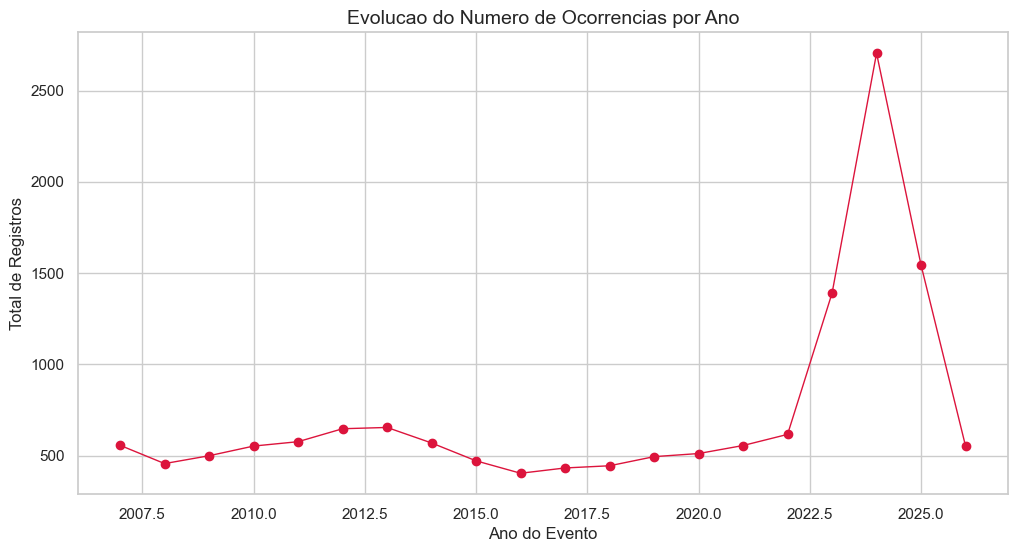

In [22]:
# Preparando os dados temporais
# Convertendo a coluna de datas para o formato oficial de tempo do Pandas, pois o dado do tipo "objetc" acaba não sendo reconhecido pelo Pandas, pois era
#apenas uma string
df_ocorrencias["data_formatada"] = pd.to_datetime(df_ocorrencias["ocorrencia_dia"], dayfirst=True, errors="coerce")

# Extraindo o ano e criando uma coluna nova apenas para ele dentro do nosso dataframe/tabela
df_ocorrencias["ano"] = df_ocorrencias["data_formatada"].dt.year

# Contando os registros e ordenando pelo index (que agora sao os anos) de forma cronologica
contagem_anos = df_ocorrencias["ano"].value_counts().sort_index()

# Desenhando a linha temporal
# O parametro marker="o" coloca um ponto visual em cada ano para facilitar a leitura exata
# O parametro linewidth deixa a linha mais grossa e visivel
plt.plot(contagem_anos.index, contagem_anos.values, color="crimson", marker="o", linewidth=1)

# Adicionando os legendas agora com o comando plt.title(), plt.xlabel() e plt.ylabel()
plt.title("Evolucao do Numero de Ocorrencias por Ano", fontsize=14)
plt.xlabel("Ano do Evento", fontsize=12)
plt.ylabel("Total de Registros", fontsize=12)

# 4. Exibindo o resultado final
plt.show()

### Como o Pandas lida com erros de datas?

Na linha de codigo acima, nos usamos a instrucao `errors="coerce"`. Isso e fundamental para trabalhar com bases de dados reais que quase sempre contém dados que podem ser inválidos, assim não precisamos tratar a coluna de antemão.

Quando pedimos para o Pandas converter uma coluna inteira para o formato de tempo, ele pode esbarrar em celulas com textos corrompidos ou informacoes inválidas. O parametro `errors` define exatamente qual sera o comportamento do sistema diante desse problema. 

Voce pode preencher essa variavel com tres comandos diferentes:

* **"coerce"**: ela forca a conversao de forma inteligente e se o Pandas achar um dado invalido, ele nao interrompe o programa. Ele apenas transforma aquela celula especifica em `NaT` (Not a Time, que é o valor nulo especifico para datas) e continua o trabalho nas outras linhas normalmente.
* **"raise"**: é o comportamento padrao do sistema, se o Pandas encontrar um unico erro, ele trava a execucao de todo o bloco e exibe um alerta na tela, então é util apenas quando voce exige extrema precisao e precisa ser avisado caso algo saia do padrao esperado.
* **"ignore"**: se houver qualquer falha, o Pandas simplesmente aborta a missao e devolve os dados originais no formato basico de texto.

### Seaborn

O Matplotlib é excelente para construir os alicerces de um gráfico do zero, mas o **Seaborn** é extremamente eficaz quando precisamos analisar dados estatísticos. A sua maior vantagem é a integração direta com o Pandas,pois le consegue ler os seus DataFrames de forma nativa e compreende os nomes das colunas sem esforço.

Enquanto no Matplotlib nós precisávamos agrupar, extrair e contar os dados manualmente para as funções antes de iniciar o desenho, o Seaborn faz todo esse cálculo matematicamente implicitamente. As funções mais fundamentais que o Seaborn possui são:

* **Gráfico de Contagem (countplot):** recebe apenas a tabela e o nome da coluna desejada, após isso o sistema automaticamente cria os agrupamentos, conta os registros idênticos e levanta as barras.
* **Gráfico de Barras com Valores (barplot):** ferramenta eficaz para cruzar uma categoria textual com uma coluna de valores numéricos, pois ele calcula automaticamente a média estatística dos valores para cada grupo e levanta as proporções.

Vamos usar iniciar mostrando o `countplot` para descobrir rapidamente qual é o volume de Acidentes e Incidentes na nossa base oficial.

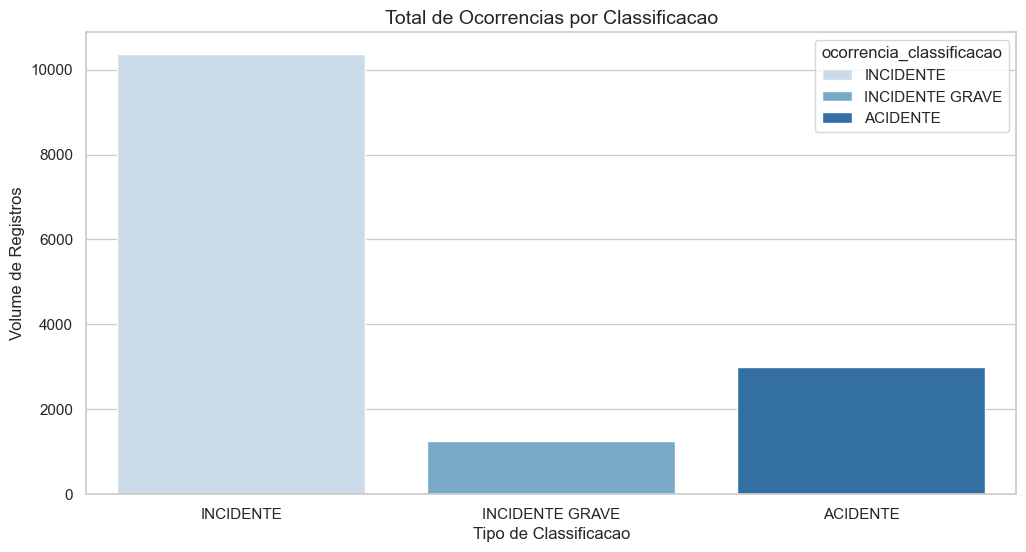

In [4]:
# Gerando o grafico de contagem automatica com Seaborn
# O parametro data recebe a nossa tabela completa (df_ocorrencias)
# O parametro x recebe o nome exato da coluna que queremos agrupar e contar
# O parametro hue é responsável por definir uma legenda no nosso gráfico com a cor e o nome de cada ocorrencia e caso legend=False, o hue não é exibido
# O parametro palette define o esquema de cores
# Outras opcoes de palette: "viridis", "crest", "magma", "Set2" ou "rocket"
sns.countplot(
    data=df_ocorrencias, 
    x="ocorrencia_classificacao", 
    hue="ocorrencia_classificacao", 
    palette="Blues",
    legend=True
)

# Adicionando titulos com Matplotlib 
# Note que as bibliotecas trabalham juntas de forma transparente, pois o sns é baseado no plt
plt.title("Total de Ocorrencias por Classificacao", fontsize=14)
plt.xlabel("Tipo de Classificacao", fontsize=12)
plt.ylabel("Volume de Registros", fontsize=12)

# Renderizando a imagem final
plt.show()

# ====================================================================
# EXEMPLO EXTRA: Cruzando valores com barplot
# ====================================================================
# Se voce precisasse cruzar categorias com alguma coluna numerica,
# como por exemplo a media de recomendacoes de seguranca por evento, 
# bastaria adicionar a variavel y indicando a coluna dos numeros:
#
# sns.barplot(data=df_ocorrencias, x="ocorrencia_classificacao", y="total_recomendacoes")
# plt.show()

Agora vamos para o comando `sns.barplot()` que é ideal se o nosso objetivo for descobrir a média de recomendações de segurança geradas por cada tipo de ocorrência, por exemplo. Nesse caso, nós precisamos cruzar uma coluna de textos com uma coluna de números, porém é exatamente para isso que serve a função `sns.barplot()`.

A grande mágica dessa função é que ela executa os cálculos matemáticos sozinha e quando você entrega os textos no eixo X e os valores numéricos no eixo Y, o Seaborn automaticamente agrupa as categorias iguais e calcula a média estatística daqueles números.

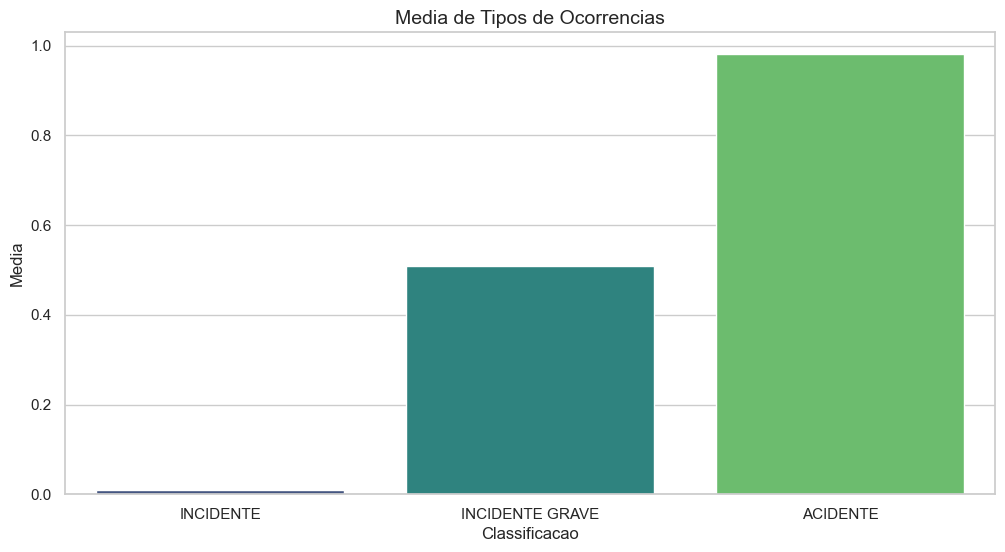

In [31]:
# Gerando o grafico de cruzamento de dados
# O parametro y recebe a coluna numerica que sofrera o calculo matematico
# O parametro errorbar=None desliga a linha vertical que marca o intervalo de confianca
# Outras opcoes para errorbar: "ci" (padrao), "pi" ou "se"
# O parametro estimator permite mudar o calculo feito pelo grafico
# Outras opcoes para estimator: "sum" (para somar tudo em vez de calcular a media), "min" ou "max"

sns.barplot(
    data=df_ocorrencias,
    x="ocorrencia_classificacao",
    y="total_recomendacoes",
    hue="ocorrencia_classificacao",
    palette="viridis",
    legend=False,
    errorbar=None
)

# Adicionando titulos com Matplotlib 
plt.title("Media de Tipos de Ocorrencias", fontsize=14)
plt.xlabel("Classificacao", fontsize=12)
plt.ylabel("Media", fontsize=12)

# Renderizando a imagem final
plt.show()

### Personalização Visual e Acabamento

Nesta etapa vamos focar nos detalhes que transformam um gráfico comum em uma apresentação profissional. Nós configuramos um tamanho padrão lá no início do projeto, mas e se você precisar de uma imagem com proporções diferentes apenas para um caso específico? 

Além disso, temos um problema muito comum na ciência de dados: textos grandes no eixo base. Quando analisamos nomes de cidades ou fabricantes empresariais, as palavras costumam ficar encavaladas umas sobre as outras, prejudicando totalmente a leitura.

Para resolver essas questões e entregar um visual elegante, vamos utilizar três ferramentas:

* **Dimensões exclusivas:** O comando `plt.figure(figsize=(10, 5))` permite ignorar a regra padrão e definir uma largura e altura únicas para o gráfico que está sendo desenhado naquele momento.
* **Ajuste de Rótulos:** O comando `plt.xticks(rotation=45)` inclina os textos da base, garantindo que mesmo os nomes mais longos tenham espaço suficiente para brilhar sem sobreposições.
* **Paletas de Cores:** O Seaborn possui conjuntos de cores harmônicas prontas. Usar paletas elegantes transmite mais credibilidade aos dados.

Vamos aplicar tudo isso na prática avaliando os fabricantes da nossa tabela de aeronaves!

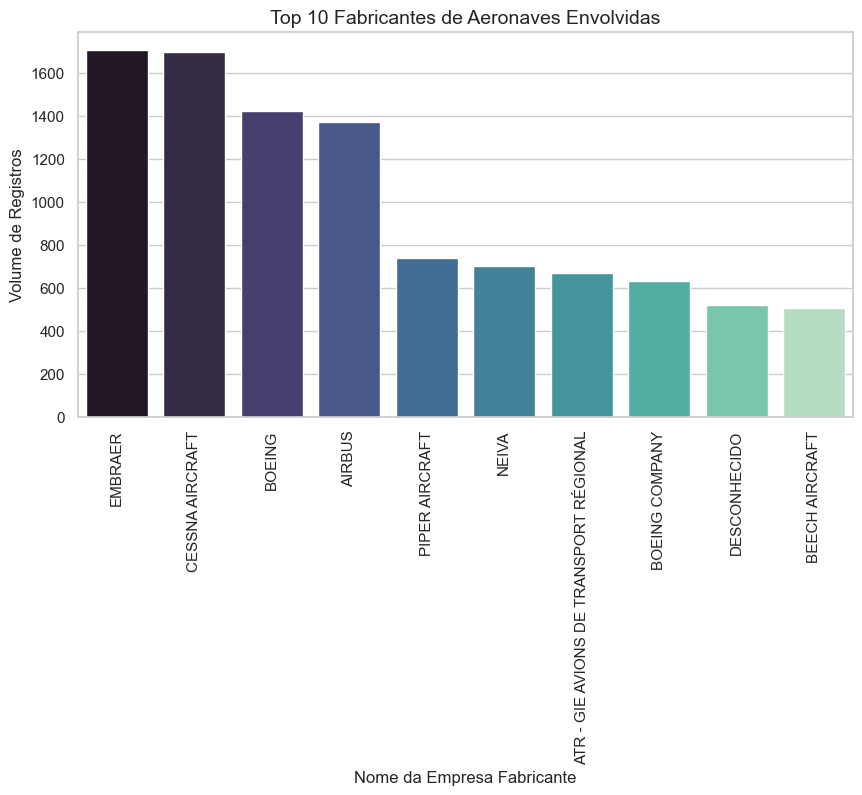

In [11]:
# 1. Preparando os dados da tabela com os tipos de aeronaves
contagem_fabricantes = df_aeronaves["aeronave_fabricante"].value_counts().head(10)

# 2. Alterando o tamanho especifico apenas desta figura
# Os valores sao (Largura, Altura). Outras opcoes comuns: (8, 8) para quadrados, (15, 5) para banners longos
plt.figure(figsize=(10, 5))

# 3. Desenhando o grafico com paleta de cores corporativa
# Outras opcoes de palette para testar: "magma", "cubehelix", "mako" ou "vlag"
sns.barplot(
    x=contagem_fabricantes.index,
    y=contagem_fabricantes.values,
    hue=contagem_fabricantes.index,
    palette="mako",
    legend=False
)

# 4. Inclinando os textos do eixo X para evitar sobreposicao
# O valor 45 representa o grau de inclinacao. Outras opcoes: 90 (totalmente em pe) ou 0 (padrao deitado)
plt.xticks(rotation=90)

# 5. Textos de apoio
plt.title("Top 10 Fabricantes de Aeronaves Envolvidas", fontsize=14)
plt.xlabel("Nome da Empresa Fabricante", fontsize=12)
plt.ylabel("Volume de Registros", fontsize=12)

# 6. Exibindo o resultado final
plt.show()

### Exportação e Compartilhamento

Todo o nosso trabalho até aqui teve um único objetivo: gerar conhecimento visual que possa ser compartilhado com outras pessoas.

Para salvar as nossas criações, usamos o comando `plt.savefig()`. O segredo para uma exportação perfeita é utilizar o parâmetro `bbox_inches="tight"`. Ele funciona como uma tesoura inteligente que ajusta as margens da imagem perfeitamente, garantindo que nenhum texto longo ou título fique cortado fora do quadro da imagem.

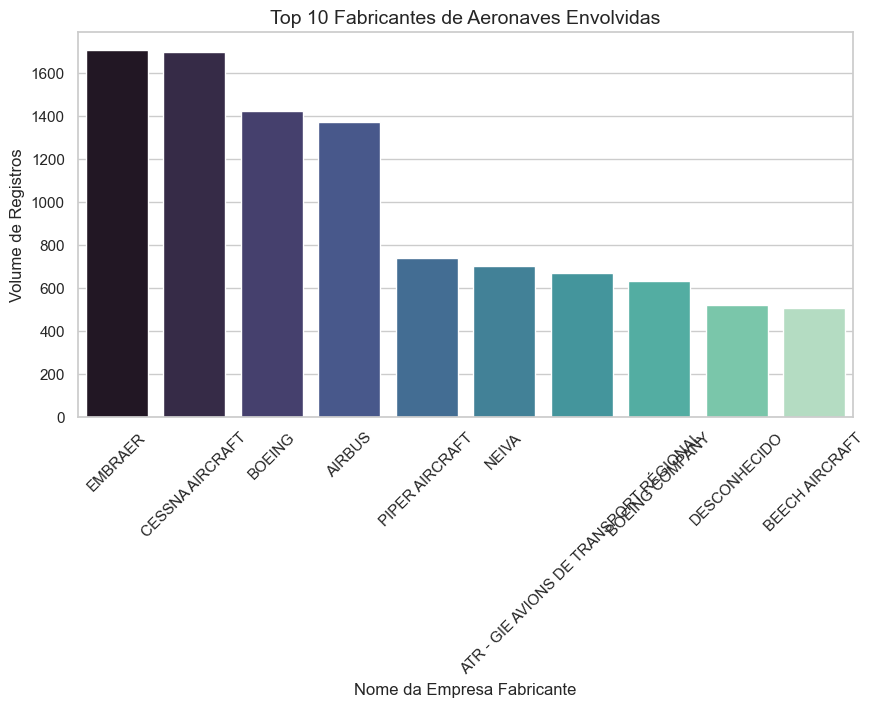

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=contagem_fabricantes.index,
    y=contagem_fabricantes.values,
    hue=contagem_fabricantes.index,
    palette="mako",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Top 10 Fabricantes de Aeronaves Envolvidas", fontsize=14)
plt.xlabel("Nome da Empresa Fabricante", fontsize=12)
plt.ylabel("Volume de Registros", fontsize=12)

# O comando de exportacao deve vir sempre ANTES do plt.show()
# O primeiro parametro e o nome do arquivo com a extensao desejada (png, jpg, pdf)
# O parametro bbox_inches ajusta as bordas para nada ser cortado
plt.savefig("grafico_fabricantes.png", bbox_inches="tight")
plt.show()

### Análise Proporcional de Risco

Analisar números absolutos pode criar falsas interpretações. Um Estado que possui milhares de voos todos os dias naturalmente terá mais acidentes registrados. A **Análise Proporcional** é muito util, em vez de perguntar "onde ocorreram mais acidentes?", nós perguntamos "de todos os eventos graves registrados em um Estado, qual possui a maior taxa percentual de incidentes graves em comparação aos acidentes reais?"

Isso requer um passo a passo matemático:
1. Filtrar a base apenas para Acidentes e Incidentes Graves.
2. Cruzar os dados criando uma tabela de matriz.
3. Somar os dois valores para descobrir o Total do Estado.
4. Dividir o valor que queremos analisar pelo Total e multiplicar por 100 para gerar a porcentagem.
5. Desenhar um gráfico de barras com a nova coluna percentual!

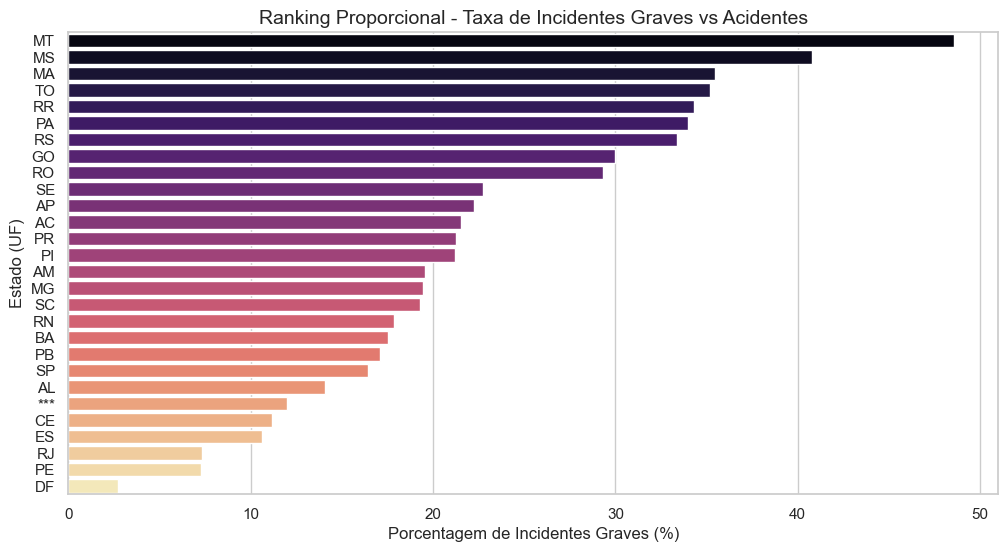

In [48]:
# Criando a matriz de cruzamento
matriz = pd.crosstab(df_ocorrencias["ocorrencia_uf"], df_ocorrencias["ocorrencia_classificacao"])

# Criando uma nvoa coluna e calculando o total de eventos criticos por Estado
matriz["Total"] = matriz["ACIDENTE"] + matriz["INCIDENTE GRAVE"] + matriz["INCIDENTE"]

# Evitando que um Estado com apenas 1 evento no historico
# apareca com 100% no topo, vamos filtrar e manter apenas os 
# Estados com um historico de pelo menos 20 eventos criticos.
matriz_valida = matriz[matriz["Total"] > 20].copy()

# 4. Calculando a proporcao percentual de Incidentes Graves
matriz_valida["Porcentagem_Incidentes_Graves"] = (matriz_valida["ACIDENTE"] / matriz_valida["Total"]) * 100

# 5. Ordenando a nossa tabela matematica do maior para o menor percentual
ranking_proporcional = matriz_valida.sort_values(by="Porcentagem_Incidentes_Graves", ascending=False)

sns.barplot(
    x=ranking_proporcional["Porcentagem_Incidentes_Graves"],
    y=ranking_proporcional.index,
    hue=ranking_proporcional.index,
    palette="magma",
    legend=False
)

# 7. Textos de apoio explicativos
plt.title("Ranking Proporcional - Taxa de Incidentes Graves vs Acidentes", fontsize=14)
plt.xlabel("Porcentagem de Incidentes Graves (%)", fontsize=12)
plt.ylabel("Estado (UF)", fontsize=12)

plt.show()

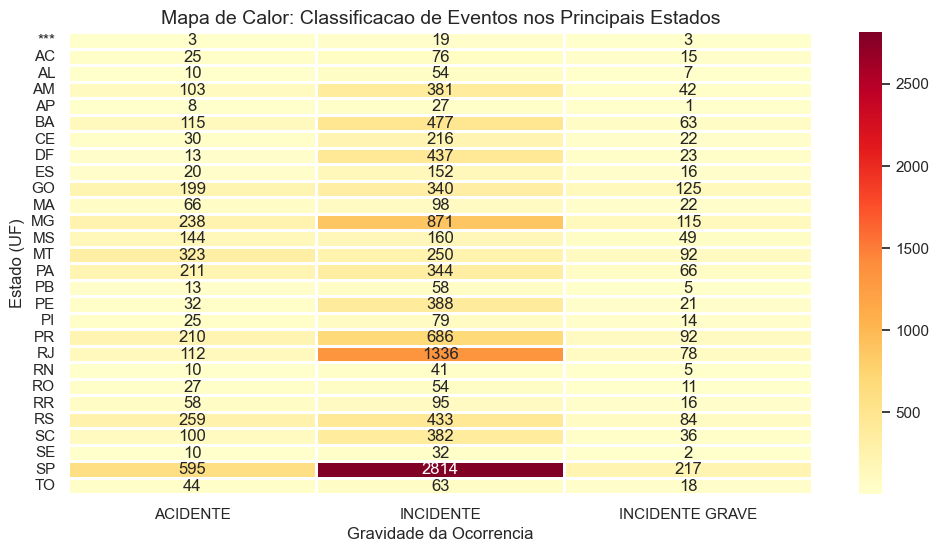

In [52]:
# Preparando os dados
estados = df_ocorrencias["ocorrencia_uf"].value_counts().index

# Filtrando a base original para manter apenas as linhas desses 10 Estados
df_filtrado = df_ocorrencias[df_ocorrencias["ocorrencia_uf"].isin(estados)]

# Matriz de Cruzamento (Tabela Dinamica)
# As linhas serao os Estados e as colunas serao as Classificacoes
matriz_ocorrencias = pd.crosstab(df_filtrado["ocorrencia_uf"], df_filtrado["ocorrencia_classificacao"])

# Desenhando o Mapa de Calor
# annot=True -escreve os numeros reais dentro de cada quadrado
# fmt="d" -garante que os numeros fiquem inteiros, sem casas decimais
# cmap="YlOrRd" -paleta que vai do amarelo para o laranja/avermelho
# linewidths=.9 -cria uma pequena borda branca entre os quadrados para facilitar a leitura
sns.heatmap(
    matriz_ocorrencias, 
    annot=True, 
    fmt="d", 
    cmap="YlOrRd", 
    linewidths=.9
)

# Descrição
plt.title("Mapa de Calor: Classificacao de Eventos nos Principais Estados", fontsize=14)
plt.xlabel("Gravidade da Ocorrencia", fontsize=12)
plt.ylabel("Estado (UF)", fontsize=12)

# Exibindo
plt.show()

## 🌐 Onde buscar inspiração?

O que fizemos aqui neste módulo foi apenas a base de análise dados. Assim, caso deseje descobrir novos tipos de gráficos, recomendo fortemente que você acesse as galerias oficiais das bibliotecas que usamos.

Nesses links você encontrará um catálogo visual imenso e basta clicar no gráfico que você achar mais bonito e o site mostrará exatamente qual código Python foi utilizado para construí-lo:
* **Galeria Oficial do Matplotlib:** [matplotlib.org/stable/gallery/index.html](https://matplotlib.org/stable/gallery/index.html)
* **Galeria Oficial do Seaborn:** [seaborn.pydata.org/examples/index.html](https://seaborn.pydata.org/examples/index.html)
